In [1]:
#* 例) ライブラリのインポート
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import matplotlib.figure as figure
from matplotlib import rcParams
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_val_predict, RandomizedSearchCV, GridSearchCV
from sklearn.inspection import permutation_importance
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
from xgboost.callback import EarlyStopping

In [ ]:
 #*　予測結果を評価し、実測値と予測値の散布図を表示する関数を定義する
def pred_plot(train_targets,train_predictions,test_targets,test_predictions,model_name):
    #* トレーニングデータに対する予測精度を RMSE・MAE・R2 で計算する
    train_mse = mean_squared_error(train_targets, train_predictions)
    train_mae = mean_absolute_error(train_targets, train_predictions)
    train_r2 = r2_score(train_targets, train_predictions)
    train_rmse = np.sqrt(train_mse)

    #* テストデータに対する予測精度を RMSE・MAE・R2 で計算する
    test_mse = mean_squared_error(test_targets, test_predictions)
    test_mae = mean_absolute_error(test_targets, test_predictions)
    test_r2 = r2_score(test_targets, test_predictions)
    test_rmse = np.sqrt(test_mse)

    print(f'\nMEGAN Training Set Performance:')
    print(f'Samples: {len(train_predictions)} | RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R²: {train_r2:.4f}')

    print(f'\nMEGAN Test Set Performance:')
    print(f'Samples: {len(test_predictions)} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    #* トレーニングデータの実測値と予測値を散布図で比較する
    ax1.scatter(train_targets, train_predictions, alpha=0.6, color='red', s=20)
    train_range = np.linspace(train_targets.min(), train_targets.max())
    ax1.plot(train_range, train_range, 'k--', lw=2)
    ax1.set_xlabel('Calculated HOMO / eV')
    ax1.set_ylabel('Predicted HOMO / eV')
    ax1.set_title(f'{model_name} Training Set (n={len(train_predictions)})\nRMSE: {train_rmse:.3f} | MAE: {train_mae:.3f} | R²: {train_r2:.3f}')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal', adjustable='box')

    #* テストデータの実測値と予測値を散布図で比較する
    ax2.scatter(test_targets, test_predictions, alpha=0.6, color='blue', s=20)
    test_range = np.linspace(test_targets.min(), test_targets.max())
    ax2.plot(test_range, test_range, 'k--', lw=2)
    ax2.set_xlabel('Calculated HOMO / eV')
    ax2.set_ylabel('Predicted HOMO / eV')
    ax2.set_title(f'{model_name} Test Set (n={len(test_predictions)})\nRMSE: {test_rmse:.3f} | MAE: {test_mae:.3f} | R²: {test_r2:.3f}')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0) 
    plt.show()

In [ ]:
 #* どの特徴量が予測に強く影響したかを調べる関数を定義
def feature_importance(model,X,model_name):
    #*学習済みモデルから、それぞれの特徴量の重要度を取り出している
    importances = model.feature_importances_
    feature_names = X.columns

    #* 特徴量の名前と重要度を表にまとめ、重要度が高い順に並べている
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    #* 重要度が高い特徴量をグラフにして、どの情報が予測に役立ったか見やすくしている
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10),palette='viridis')
    plt.title(f'Feature Importances in {model_name}')
    plt.show()

In [ ]:
 #*CSVファイルを読み込んで、分子のデータを表として表示している
df = pd.read_csv('Python_seminar_NN_rdkit_descriptors.csv')
df


,cid,smiles,mw,homo,mol,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,194053,[O-][N+](=O)NCCN,105.095880,-10.258420,<rdkit.Chem.rdchem.Mol object at 0x131ddd9a0>,9.397083,9.397083,0.229167,-0.618194,0.345966,...,0,0,0,0,0,0,0,0,0,0
1,170434,CCN(CC(=O)O)N=O,132.117920,-10.354748,<rdkit.Chem.rdchem.Mol object at 0x131ddd460>,9.886944,9.886944,0.319444,-1.044954,0.433865,...,0,0,0,0,0,0,0,0,0,0
2,107666,O=NN=C(N([N+](=O)[O-])C)N,147.092800,-9.281803,<rdkit.Chem.rdchem.Mol object at 0x131dddd90>,9.842500,9.842500,0.376389,-0.829352,0.178633,...,0,0,0,0,0,0,0,0,0,0
3,153173,COCN(CC(C)C)N=O,146.187560,-9.378948,<rdkit.Chem.rdchem.Mol object at 0x131ddd3f0>,10.026389,10.026389,0.279444,0.279444,0.332576,...,0,0,0,0,0,0,0,0,0,0
4,125042,CC(=O)C(=O)NN,102.091940,-10.067668,<rdkit.Chem.rdchem.Mol object at 0x131ddf370>,9.925926,9.925926,0.581019,-0.763889,0.184291,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,53811893,Cc1n[nH]c(=C)s1,114.168840,-8.495939,<rdkit.Chem.rdchem.Mol object at 0x1335094d0>,3.847222,3.847222,0.914352,0.914352,0.510156,...,1,0,0,0,0,0,0,0,0,0
9996,53963834,NN1SCC=N1,103.146200,-8.663017,<rdkit.Chem.rdchem.Mol object at 0x133509540>,5.133102,5.133102,0.913194,0.913194,0.341070,...,0,0,0,0,0,0,0,0,0,0
9997,53799617,NN=C(C(Cl)(F)F)N,143.523066,-9.609156,<rdkit.Chem.rdchem.Mol object at 0x1335095b0>,11.545802,11.545802,1.084105,-3.616319,0.179123,...,0,0,0,0,0,0,0,0,0,0
9998,53873073,NN1CN=CS1,103.146200,-9.251599,<rdkit.Chem.rdchem.Mol object at 0x133509620>,5.206019,5.206019,0.629630,0.629630,0.341070,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#* 予測に直接使わない列を取り除き、機械学習に使いやすいデータにしている
drop_list = ['cid', 'smiles', 'mw', 'mol']
df_clean = df.drop(columns=drop_list)
df_clean

,homo,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,-10.258420,9.397083,9.397083,0.229167,-0.618194,0.345966,8.142857,105.097,98.041,105.053826,...,0,0,0,0,0,0,0,0,0,0
1,-10.354748,9.886944,9.886944,0.319444,-1.044954,0.433865,8.555556,132.119,124.055,132.053492,...,0,0,0,0,0,0,0,0,0,0
2,-9.281803,9.842500,9.842500,0.376389,-0.829352,0.178633,10.700000,147.094,142.054,147.039239,...,0,0,0,0,0,0,0,0,0,0
3,-9.378948,10.026389,10.026389,0.279444,0.279444,0.332576,10.000000,146.190,132.078,146.105528,...,0,0,0,0,0,0,0,0,0,0
4,-10.067668,9.925926,9.925926,0.581019,-0.763889,0.184291,7.714286,102.093,96.045,102.042927,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-8.495939,3.847222,3.847222,0.914352,0.914352,0.510156,19.000000,114.173,108.125,114.025169,...,1,0,0,0,0,0,0,0,0,0
9996,-8.663017,5.133102,5.133102,0.913194,0.913194,0.341070,19.833333,103.150,98.110,103.020418,...,0,0,0,0,0,0,0,0,0,0
9997,-9.609156,11.545802,11.545802,1.084105,-3.616319,0.179123,14.125000,143.524,139.492,143.006181,...,0,0,0,0,0,0,0,0,0,0
9998,-9.251599,5.206019,5.206019,0.629630,0.629630,0.341070,22.833333,103.150,98.110,103.020418,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
 #*目的変数を homo に設定し、目的変数 y と説明変数 x に分ける
target = 'homo'
y = df_clean[target] 
x = df_clean.drop(columns=[target]) 

#* データをトレーニングデータ80%、テストデータ20%に分割する
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, shuffle=True,random_state=42) 

#*トレーニングデータの目的変数と説明変数を標準化する
auto_y_train = (y_train - y_train.mean()) / y_train.std()
auto_X_train = (X_train - X_train.mean()) / X_train.std()
#*テストデータの説明変数を、トレーニングデータの平均と標準偏差を使って標準化する
auto_X_test = (X_test - X_train.mean()) / X_train.std()

print(f'目的変数:{target},説明変数:{x.shape[1]},データ数:{x.shape[0]}')
print(f'トレーニングセット:{X_train.shape[0]},テストセット:{X_test.shape[0]}')

目的変数:homo,説明変数:217,データ数:10000
トレーニングセット:8000,テストセット:2000



MEGAN Training Set Performance:
Samples: 8000 | RMSE: 0.0987 | MAE: 0.0734 | R²: 0.9801

MEGAN Test Set Performance:
Samples: 2000 | RMSE: 0.2602 | MAE: 0.1905 | R²: 0.8562


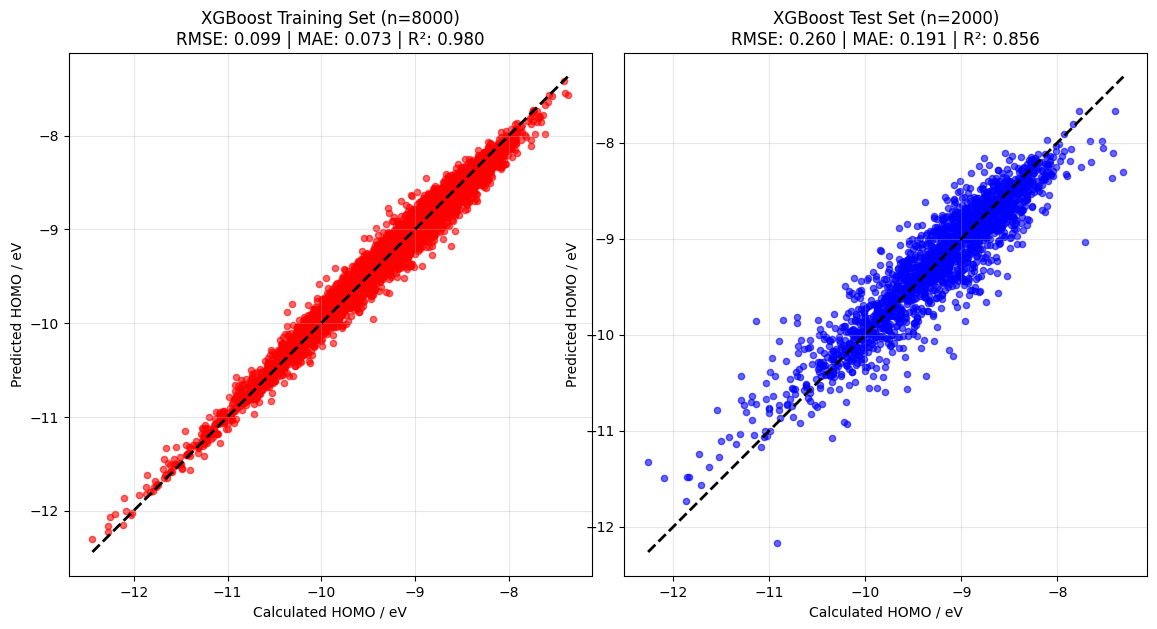

/var/folders/mw/1xx3mj955bn6l24bbqrbd3s00000gp/T/ipykernel_80014/2200265922.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10),palette='viridis')


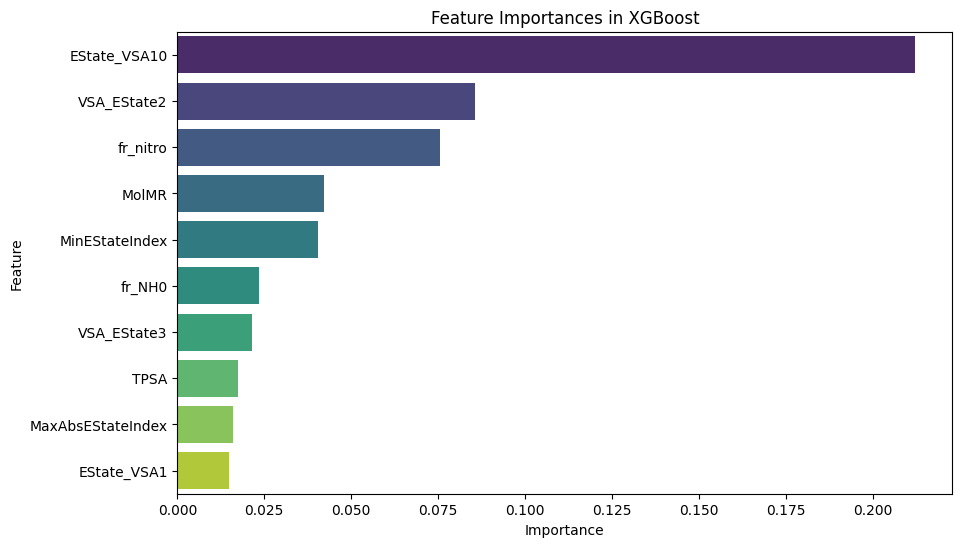

In [ ]:
 #XGBoost
 #*XGBoost 回帰モデルを作成する
model_name = 'XGBoost'
model = xgb.XGBRegressor()

#* 標準化したトレーニングデータを使ってモデルを学習させる
model.fit(auto_X_train,auto_y_train)

#* トレーニングデータに対して予測を行い、標準化された予測値を元のスケールに戻す
autoscaled_pred_y_train = model.predict(auto_X_train)  
pred_y_train = autoscaled_pred_y_train * y_train.std() + y_train.mean() #*
pred_y_train = pd.DataFrame(pred_y_train, index=auto_X_train.index, columns=['pred_y'])

#* テストデータに対して予測を行い、標準化された予測値を元のスケールに戻す
autoscaled_pred_y_test = model.predict(auto_X_test)  
pred_y_test = autoscaled_pred_y_test * y_train.std() + y_train.mean() #* (pred_y_trainと同じ)
pred_y_test = pd.DataFrame(pred_y_test, index=X_test.index, columns=['pred_y'])

pred_plot(y_train,pred_y_train,y_test,pred_y_test,model_name) #* 実測値と予測値を比較する散布図を表示し、予測精度を確認する
feature_importance(model,auto_X_train,model_name) #* 学習済みモデルにおける説明変数の重要度を表示する


第二回の宿題はここまでです。
余裕があればこの下もやってみてください。第3回で勉強する範囲です。

早期停止が実行されたイテレーション数: 1038

MEGAN Training Set Performance:
Samples: 8000 | RMSE: 0.1267 | MAE: 0.0662 | R²: 0.9673

MEGAN Test Set Performance:
Samples: 2000 | RMSE: 0.2510 | MAE: 0.1830 | R²: 0.8661


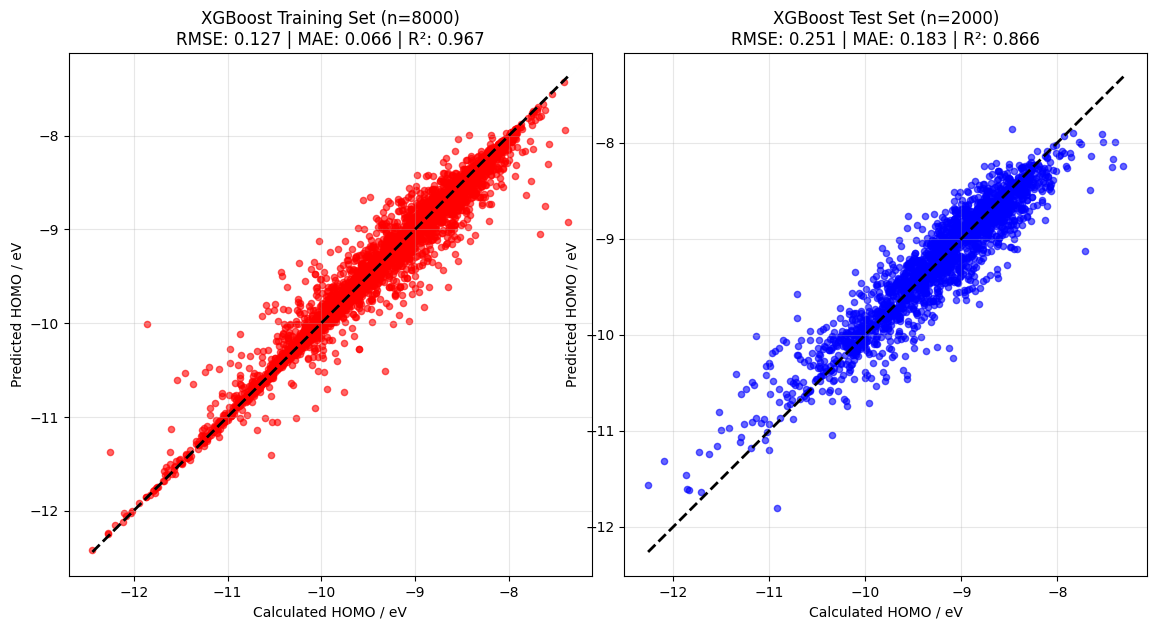

/var/folders/2r/2w6_2by54h92_12v16pjtjr00000gp/T/ipykernel_15998/2309135372.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10),palette='viridis')


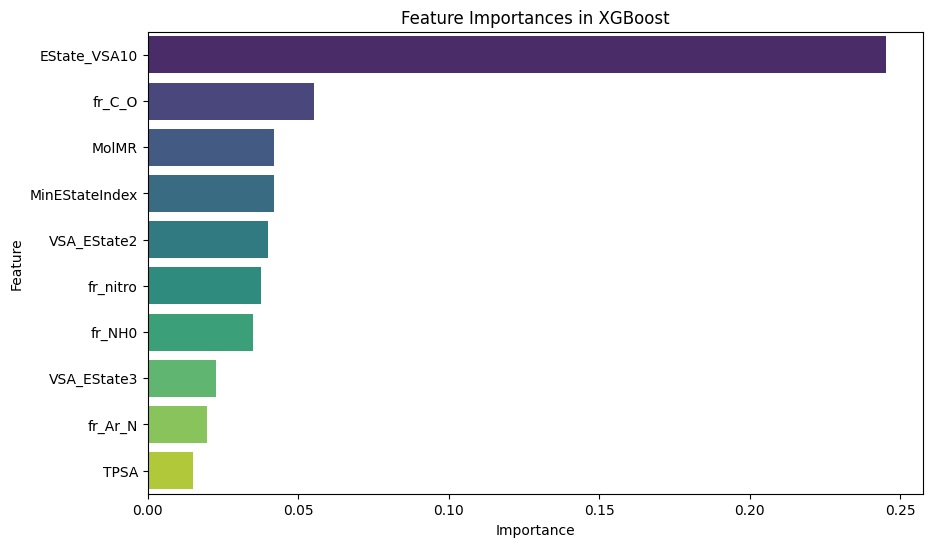

In [ ]:
#*
model_name = 'XGBoost'
X_trainXGB, X_valid, y_trainXGB, y_valid = train_test_split(auto_X_train, auto_y_train, test_size=0.2, shuffle=True,random_state=42)

model = model = xgb.XGBRegressor(
    n_estimators=10000, 
    learning_rate=0.05,
    random_state=42,
    eval_metric='rmse',  
    early_stopping_rounds=50, 
)
model.fit(
    X_trainXGB,y_trainXGB,
    eval_set=[(X_valid,y_valid)],
    verbose=0
)
autoscaled_pred_y_train = model.predict(auto_X_train)  # y の推定
pred_y_train = autoscaled_pred_y_train * y_train.std() + y_train.mean() #スケールを元に戻す
pred_y_train = pd.DataFrame(pred_y_train, index=auto_X_train.index, columns=['pred_y'])

 #*
stopped_at = model.best_iteration
print(f"早期停止が実行されたイテレーション数: {stopped_at}")
#*
autoscaled_pred_y_test = model.predict(auto_X_test)  # y の推定
pred_y_test = autoscaled_pred_y_test * y_train.std() + y_train.mean() #*スケールを元に戻す
pred_y_test = pd.DataFrame(pred_y_test, index=X_test.index, columns=['pred_y'])

pred_plot(y_train,pred_y_train,y_test,pred_y_test,model_name)
feature_importance(model,X_trainXGB,model_name)